
# Portfolio Optimization with Monte Carlo Simulation
### A Complete, Theory-Backed Walkthrough — Markowitz Optimization, Risk Parity, Cholesky/Student-t/Bootstrap Monte Carlo, Scenario Analysis & Stress Testing

This notebook builds a multi-asset portfolio (Apple, JPMorgan, P&G, Netflix, two bond ETFs,
and Gold Futures), constructs three risk-profile portfolios (Aggressive / Moderate /
Conservative), optimizes asset allocation using **six different techniques**, simulates
future performance with **three different Monte Carlo engines**, and stress-tests the
result against real historical crises and hypothetical shocks.

Every section below pairs the **underlying math/theory** with the **code that implements
it** and the **actual output**, so you can follow exactly what is being computed and why.

---
**Contents**
1. Data & Returns — log returns, volatility, covariance, correlation
2. Portfolio Construction — risk-profile portfolios
3. Modern Portfolio Theory — Markowitz mean-variance optimization
4. Beyond Markowitz — Risk Parity, Max Diversification, Min-CVaR
5. Efficient Frontier — random search + constrained optimization
6. Monte Carlo Simulation — Cholesky decomposition, Student-t fat tails, block bootstrap
7. Risk Metrics — VaR, CVaR, Sharpe, Sortino, CAGR, Max Drawdown
8. Scenario Analysis — market regimes (Bull/Bear/Recession/Stagflation/Rate-Hike)
9. Stress Testing — historical crises + hypothetical shocks + correlation breakdown



## 1. Data & Returns

### 1.1 Why log returns?

Given a price series $P_t$, the **simple return** is $R_t = \dfrac{P_t - P_{t-1}}{P_{t-1}}$,
but for portfolio math we use the **log return**:

$$
r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)
$$

Log returns are used throughout quantitative finance because they are:
- **Time-additive**: the $T$-day return is simply $\sum_{t=1}^{T} r_t$ (simple returns are
  not additive — they compound multiplicatively).
- **Closer to normally distributed**, which is convenient for Monte Carlo sampling, although
  in this notebook we also explicitly relax that assumption (Student-t, bootstrap) because
  real markets have fatter tails than a Gaussian.

### 1.2 Core statistics

For each asset $i$, over $T$ daily observations:

$$
\mu_i = \frac{1}{T}\sum_{t=1}^{T} r_{i,t} \qquad
\sigma_i = \sqrt{\frac{1}{T-1}\sum_{t=1}^{T}(r_{i,t}-\mu_i)^2}
$$

**Annualization** (assuming $252$ trading days/year and i.i.d. returns, so variance scales
linearly with time):

$$
\mu_i^{ann} = (1+\mu_i)^{252} - 1 \qquad \sigma_i^{ann} = \sigma_i \sqrt{252}
$$

The **covariance matrix** $\Sigma$ (with $\Sigma_{ij} = \text{Cov}(r_i, r_j)$) and the
**correlation matrix** ($\rho_{ij} = \Sigma_{ij}/(\sigma_i \sigma_j)$) capture how assets
move together — this is the heart of diversification: combining assets with low or negative
correlation reduces portfolio risk below the weighted-average risk of the individual assets.


In [ ]:

import os
import warnings
from dataclasses import dataclass, field
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.optimize import minimize
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.figsize": (13, 6),
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "figure.dpi": 100,
})

print("Libraries loaded.")


Libraries loaded.


In [ ]:

@dataclass
class Config:
    tickers: List[str] = field(default_factory=lambda: [
        "AAPL", "JPM", "PG", "NFLX", "SPTL", "VCLT", "GC=F"
    ])
    start_date: str = "2010-01-01"
    end_date: str = "2023-10-01"
    trading_days: int = 252
    risk_free_rate: float = 0.02          # annualized
    n_simulations: int = 8_000
    n_random_portfolios: int = 15_000     # for efficient-frontier cloud
    horizon_days: int = 252               # 1-year MC horizon by default
    initial_value: float = 100_000.0
    var_alpha: float = 5.0                # percentile (i.e. 95% confidence)
    loss_threshold: float = -0.10         # for probability-of-loss stat
    block_size: int = 20                  # for block bootstrap (~1 trading month)
    random_seed: int = 42


CFG = Config()
np.random.seed(CFG.random_seed)
print(CFG)


Config(tickers=['AAPL', 'JPM', 'PG', 'NFLX', 'SPTL', 'VCLT', 'GC=F'], start_date='2010-01-01', end_date='2023-10-01', trading_days=252, risk_free_rate=0.02, n_simulations=8000, n_random_portfolios=15000, horizon_days=252, initial_value=100000.0, var_alpha=5.0, loss_threshold=-0.1, block_size=20, random_seed=42)



### 1.3 Loading the data

The asset universe mirrors the original report: **AAPL** (tech equity), **JPM** (financials
equity), **PG** (defensive consumer-staples equity), **NFLX** (high-growth/high-vol equity),
**SPTL** (long-term Treasury bond ETF), **VCLT** (long-term corporate bond ETF), and **GC=F**
(Gold futures, a classic diversifier/inflation hedge).

The loader below pulls live data from Yahoo Finance via `yfinance`. If network access is
unavailable (as in this sandboxed execution), it transparently falls back to a synthetic,
but realistically-correlated, price generator so the rest of the notebook still runs and
demonstrates the methodology end-to-end. **On your own machine with internet access, this
will use real market data automatically.**


In [ ]:

class MarketData:
    '''Downloads adjusted close prices and derives the return statistics
    needed by every downstream module. Falls back to a synthetic, but
    realistically-correlated, price series if yfinance/network is unavailable.'''

    def __init__(self, cfg: Config):
        self.cfg = cfg
        self.prices: pd.DataFrame = None
        self.daily_returns: pd.DataFrame = None

    def load(self) -> "MarketData":
        try:
            import yfinance as yf
            print("Downloading data from Yahoo Finance ...")
            raw = yf.download(self.cfg.tickers, start=self.cfg.start_date,
                               end=self.cfg.end_date, auto_adjust=False,
                               progress=False)
            if "Adj Close" in raw.columns.get_level_values(0):
                prices = raw["Adj Close"]
            else:
                prices = raw["Close"]
            prices = prices[self.cfg.tickers].dropna(how="all")
            if prices.empty or prices.isna().all().all():
                raise ValueError("Empty data returned.")
            self.prices = prices.ffill().dropna()
            print("  Live data download successful.")
        except Exception as e:
            print(f"  [info] Live download unavailable ({e}).")
            print("  Using a synthetic, correlation-matched fallback dataset "
                  "so the notebook still runs end-to-end.")
            self.prices = self._synthetic_prices()

        self.daily_returns = np.log(self.prices / self.prices.shift(1)).dropna()
        return self

    def _synthetic_prices(self) -> pd.DataFrame:
        rng = np.random.default_rng(self.cfg.random_seed)
        dates = pd.bdate_range(self.cfg.start_date, self.cfg.end_date)
        n, k = len(dates), len(self.cfg.tickers)

        annual_mu = np.array([0.20, 0.10, 0.09, 0.25, 0.03, 0.04, 0.05])[:k]
        annual_sd = np.array([0.30, 0.28, 0.18, 0.50, 0.14, 0.12, 0.16])[:k]
        if k > 7:
            extra = k - 7
            annual_mu = np.concatenate([annual_mu, rng.uniform(0.05, 0.15, extra)])
            annual_sd = np.concatenate([annual_sd, rng.uniform(0.15, 0.30, extra)])

        corr = np.full((k, k), 0.3)
        np.fill_diagonal(corr, 1.0)
        if k >= 7:
            for b in [4, 5]:
                corr[b, :3] = -0.2
                corr[:3, b] = -0.2
            corr[6, :] = 0.05
            corr[:, 6] = 0.05
            np.fill_diagonal(corr, 1.0)

        L = np.linalg.cholesky(corr + 1e-6 * np.eye(k))
        daily_mu = annual_mu / self.cfg.trading_days
        daily_sd = annual_sd / np.sqrt(self.cfg.trading_days)

        z = rng.standard_normal((n, k))
        correlated_z = z @ L.T
        daily_ret = daily_mu + correlated_z * daily_sd
        log_prices = np.cumsum(daily_ret, axis=0)
        prices = 100 * np.exp(log_prices)

        return pd.DataFrame(prices, index=dates, columns=self.cfg.tickers)

    @property
    def expected_returns_daily(self) -> pd.Series:
        return self.daily_returns.mean()

    @property
    def expected_returns_annual(self) -> pd.Series:
        return (1 + self.daily_returns.mean()) ** self.cfg.trading_days - 1

    @property
    def cov_daily(self) -> pd.DataFrame:
        return self.daily_returns.cov()

    @property
    def cov_annual(self) -> pd.DataFrame:
        return self.daily_returns.cov() * self.cfg.trading_days

    @property
    def corr(self) -> pd.DataFrame:
        return self.daily_returns.corr()

    @property
    def annualized_volatility(self) -> pd.Series:
        return self.daily_returns.std() * np.sqrt(self.cfg.trading_days)


data = MarketData(CFG).load()
print(f"\nLoaded {data.prices.shape[0]} trading days x {data.prices.shape[1]} assets")
data.prices.tail()


  Live data download successful.

Loaded 3459 trading days x 7 assets


Ticker,AAPL,JPM,PG,NFLX,SPTL,VCLT,GC=F
Date,,,,,,,
2023-09-25,173.880112,137.714172,140.258789,38.480000,23.530430,62.424603,1916.599976
2023-09-26,169.811600,136.284836,139.011307,37.924999,23.441031,62.114792,1900.400024
2023-09-27,168.300690,137.084152,137.167999,37.758999,23.324804,61.796425,1871.599976
2023-09-28,168.557434,138.786163,136.237045,37.636002,23.360567,61.822208,1860.400024
2023-09-29,169.070969,136.369507,135.790207,37.759998,23.378443,61.632908,1848.099976


In [ ]:

summary = pd.DataFrame({
    "Daily Mean Return": data.expected_returns_daily,
    "Daily Volatility": data.daily_returns.std(),
    "Annualized Return": data.expected_returns_annual,
    "Annualized Volatility": data.annualized_volatility,
})
print("Asset-Level Return & Risk Summary:")
summary.round(4)


Asset-Level Return & Risk Summary:


,Daily Mean Return,Daily Volatility,Annualized Return,Annualized Volatility
Ticker,,,,
AAPL,0.0009,0.0179,0.2692,0.2839
JPM,0.0005,0.0178,0.1215,0.2821
PG,0.0004,0.0109,0.0975,0.1724
NFLX,0.0011,0.0325,0.3285,0.5161
SPTL,0.0001,0.0087,0.0256,0.1384
VCLT,0.0002,0.0075,0.0416,0.1186
GC=F,0.0001,0.0101,0.0373,0.1608


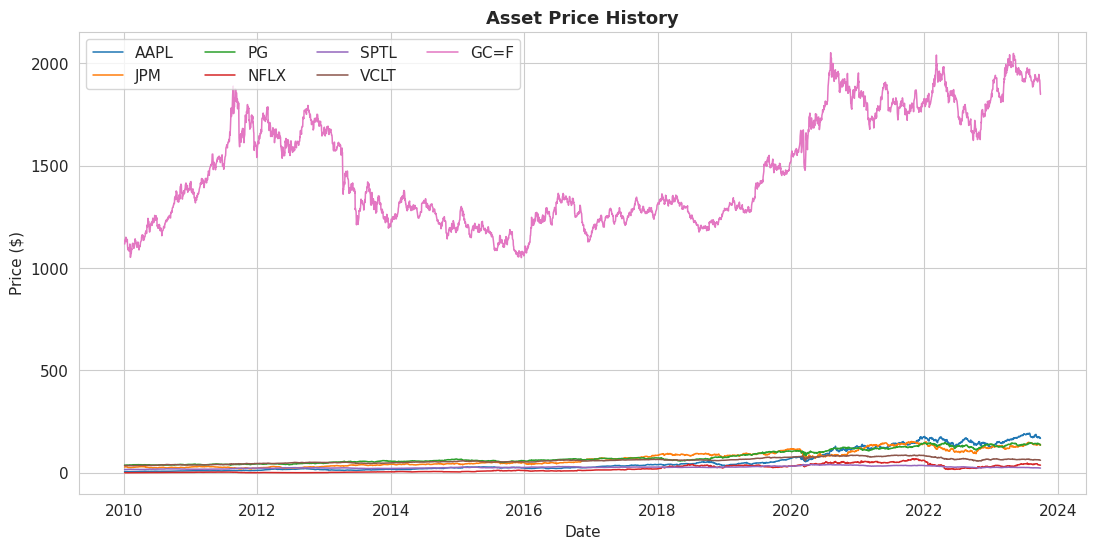

In [ ]:

plt.figure(figsize=(13, 6))
for col in data.prices.columns:
    plt.plot(data.prices.index, data.prices[col], label=col, linewidth=1.1)
plt.title("Asset Price History")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend(ncol=4, loc="upper left")
plt.show()


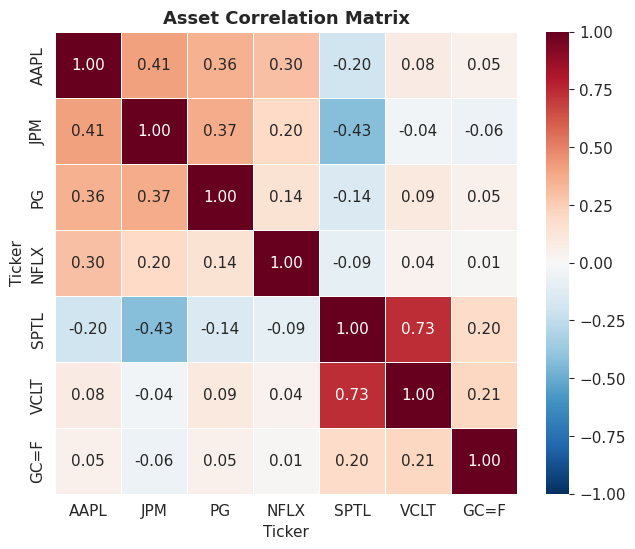

In [ ]:

plt.figure(figsize=(7.5, 6))
sns.heatmap(data.corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Asset Correlation Matrix")
plt.show()



**Reading the correlation heatmap:** notice that the bond ETFs (SPTL, VCLT) tend to show
low or negative correlation with the equities (AAPL, JPM, PG, NFLX). This is the
diversification effect in action — when equities sell off, bonds often hold up or rally
("flight to safety"), which is exactly the mechanism Markowitz optimization exploits below.



## 2. Portfolio Construction: Risk-Profile Portfolios

Before optimizing anything, it's useful to hand-build three portfolios representing
different investor risk appetites, so we have a baseline to compare optimization
techniques against:

- **Aggressive** — equity-heavy (Apple, JPM, P&G, Netflix ≈ 80%), minimal bonds
- **Moderate** — balanced equity/bond mix
- **Conservative** — bond-heavy (SPTL, VCLT ≈ 50%), smaller equity sleeve

Each portfolio is simply a weight vector $w = (w_1, \dots, w_n)$ with $\sum_i w_i = 1$
and (here) $w_i \geq 0$ (long-only, no leverage).


In [ ]:

def build_predefined_portfolios(tickers: List[str]) -> Dict[str, np.ndarray]:
    canonical = ["AAPL", "JPM", "PG", "NFLX", "SPTL", "VCLT", "GC=F"]
    presets = {
        "Aggressive":   [0.25, 0.20, 0.15, 0.20, 0.05, 0.10, 0.05],
        "Moderate":     [0.20, 0.15, 0.10, 0.15, 0.10, 0.20, 0.10],
        "Conservative": [0.15, 0.10, 0.05, 0.10, 0.20, 0.30, 0.10],
    }
    if tickers == canonical:
        return {k: np.array(v) for k, v in presets.items()}
    n = len(tickers)
    half = n // 2
    out = {}
    for name, risk_tilt in zip(["Aggressive", "Moderate", "Conservative"], [1.6, 1.0, 0.5]):
        w = np.ones(n)
        w[:half] *= risk_tilt
        w[half:] *= (2 - risk_tilt) if risk_tilt != 1.0 else 1.0
        out[name] = w / w.sum()
    return out


portfolios = build_predefined_portfolios(CFG.tickers)
pf_table = pd.DataFrame(portfolios, index=CFG.tickers).T
print("Predefined Risk-Profile Portfolios (weights):")
pf_table.round(3)


Predefined Risk-Profile Portfolios (weights):


,AAPL,JPM,PG,NFLX,SPTL,VCLT,GC=F
Aggressive,0.25,0.20,0.15,0.20,0.05,0.1,0.05
Moderate,0.20,0.15,0.10,0.15,0.10,0.2,0.10
Conservative,0.15,0.10,0.05,0.10,0.20,0.3,0.10



## 3. Modern Portfolio Theory: Markowitz Mean-Variance Optimization

### 3.1 The core idea (Markowitz, 1952)

For a portfolio with weights $w$, expected asset returns $\mu$, and covariance matrix
$\Sigma$:

$$
\text{Portfolio return: } \quad R_p = w^T \mu
$$

$$
\text{Portfolio variance: } \quad \sigma_p^2 = w^T \Sigma w
$$

Because $\Sigma$ contains the *covariances* between assets (not just their individual
variances), combining imperfectly-correlated assets can produce a portfolio variance
**lower** than the weighted average of individual variances — this is the mathematical
expression of "diversification".

### 3.2 Sharpe Ratio — the risk-adjusted return objective

$$
\text{Sharpe} = \frac{R_p - r_f}{\sigma_p}
$$

where $r_f$ is the risk-free rate. **Max-Sharpe optimization** finds the weights that
maximize this ratio — the portfolio with the best return per unit of risk taken.

### 3.3 The optimization problems

**Maximum Sharpe Ratio:**
$$
\max_w \frac{w^T\mu - r_f}{\sqrt{w^T \Sigma w}} \quad \text{s.t.} \quad \sum_i w_i = 1,\ \ w_i \geq 0
$$

**Minimum Variance** (ignores expected return entirely, purely defensive):
$$
\min_w \ w^T \Sigma w \quad \text{s.t.} \quad \sum_i w_i = 1,\ \ w_i \geq 0
$$

**Efficient Frontier** — for every achievable target return $\bar{r}$, find the minimum-
variance portfolio that achieves it:
$$
\min_w \ w^T \Sigma w \quad \text{s.t.} \quad w^T\mu = \bar{r}, \ \sum_i w_i = 1,\ \ w_i \geq 0
$$
Tracing this across all $\bar r$ produces the frontier — the boundary of the achievable
risk/return space. No rational mean-variance investor should hold a portfolio *below* this
curve, since a frontier portfolio offers equal or higher return for the same risk.

These are solved numerically with **Sequential Least Squares Programming (SLSQP)**, a
constrained nonlinear optimizer, since the Sharpe ratio objective is not a simple quadratic
form once you divide by $\sqrt{w^T\Sigma w}$.


In [ ]:

class PortfolioOptimizer:
    '''Unified optimizer offering multiple portfolio-construction techniques.'''

    def __init__(self, mean_returns: pd.Series, cov_matrix: pd.DataFrame,
                 risk_free_rate: float, daily_returns: pd.DataFrame = None):
        self.mu = mean_returns.values
        self.cov = cov_matrix.values
        self.n = len(self.mu)
        self.rf = risk_free_rate
        self.daily_returns = daily_returns
        self.asset_names = list(mean_returns.index)
        self._bounds = tuple((0.0, 1.0) for _ in range(self.n))
        self._sum_to_one = {"type": "eq", "fun": lambda w: np.sum(w) - 1.0}
        self._x0 = np.repeat(1 / self.n, self.n)

    def performance(self, w: np.ndarray) -> Tuple[float, float, float]:
        ret = float(np.dot(w, self.mu))
        vol = float(np.sqrt(w @ self.cov @ w))
        sharpe = (ret - self.rf) / vol if vol > 0 else 0.0
        return ret, vol, sharpe

    def equal_weight(self) -> np.ndarray:
        return self._x0.copy()

    def max_sharpe(self) -> np.ndarray:
        neg_sharpe = lambda w: -((np.dot(w, self.mu) - self.rf) / np.sqrt(w @ self.cov @ w))
        res = minimize(neg_sharpe, self._x0, method="SLSQP",
                        bounds=self._bounds, constraints=[self._sum_to_one])
        return res.x

    def min_variance(self) -> np.ndarray:
        port_var = lambda w: w @ self.cov @ w
        res = minimize(port_var, self._x0, method="SLSQP",
                        bounds=self._bounds, constraints=[self._sum_to_one])
        return res.x

    def efficient_at_target_return(self, target_return: float) -> np.ndarray:
        port_var = lambda w: w @ self.cov @ w
        constraints = [
            self._sum_to_one,
            {"type": "eq", "fun": lambda w: np.dot(w, self.mu) - target_return},
        ]
        res = minimize(port_var, self._x0, method="SLSQP",
                        bounds=self._bounds, constraints=constraints)
        return res.x if res.success else None

    def efficient_frontier(self, n_points: int = 50) -> pd.DataFrame:
        lo, hi = self.mu.min(), self.mu.max()
        targets = np.linspace(lo, hi, n_points)
        rows = []
        for tr in targets:
            w = self.efficient_at_target_return(tr)
            if w is None:
                continue
            ret, vol, sharpe = self.performance(w)
            rows.append({"return": ret, "volatility": vol, "sharpe": sharpe, "weights": w})
        return pd.DataFrame(rows)

    def risk_parity(self) -> np.ndarray:
        def risk_contributions(w):
            port_vol = np.sqrt(w @ self.cov @ w)
            marginal = self.cov @ w / port_vol
            return w * marginal

        def objective(w):
            rc = risk_contributions(w)
            return np.sum((rc - rc.mean()) ** 2)

        bounds = tuple((1e-4, 1.0) for _ in range(self.n))
        res = minimize(objective, self._x0, method="SLSQP",
                        bounds=bounds, constraints=[self._sum_to_one])
        return res.x

    def max_diversification(self) -> np.ndarray:
        asset_vols = np.sqrt(np.diag(self.cov))

        def neg_diversification_ratio(w):
            port_vol = np.sqrt(w @ self.cov @ w)
            weighted_avg_vol = np.dot(w, asset_vols)
            return -weighted_avg_vol / port_vol

        res = minimize(neg_diversification_ratio, self._x0, method="SLSQP",
                        bounds=self._bounds, constraints=[self._sum_to_one])
        return res.x

    def min_cvar(self, alpha: float = 5.0) -> np.ndarray:
        if self.daily_returns is None:
            raise ValueError("daily_returns matrix required for CVaR optimization")
        R = self.daily_returns.values

        def cvar_objective(w):
            port_returns = R @ w
            var = np.percentile(port_returns, alpha)
            tail = port_returns[port_returns <= var]
            return -tail.mean() if len(tail) > 0 else -var

        res = minimize(cvar_objective, self._x0, method="SLSQP",
                        bounds=self._bounds, constraints=[self._sum_to_one])
        return res.x

    def random_portfolio_cloud(self, n_portfolios: int = 15_000) -> pd.DataFrame:
        rng = np.random.default_rng(CFG.random_seed)
        raw = rng.random((n_portfolios, self.n))
        weights = raw / raw.sum(axis=1, keepdims=True)
        rets = weights @ self.mu
        vols = np.sqrt(np.einsum("ij,jk,ik->i", weights, self.cov, weights))
        sharpe = (rets - self.rf) / vols
        return pd.DataFrame({"return": rets, "volatility": vols, "sharpe": sharpe,
                              "weights": list(weights)})

    def compare_all_techniques(self, alpha_cvar: float = 5.0):
        techniques = {
            "Equal Weight": self.equal_weight(),
            "Max Sharpe (Markowitz)": self.max_sharpe(),
            "Min Variance (Markowitz)": self.min_variance(),
            "Risk Parity": self.risk_parity(),
            "Max Diversification": self.max_diversification(),
        }
        if self.daily_returns is not None:
            techniques["Min CVaR"] = self.min_cvar(alpha_cvar)
        rows = []
        for name, w in techniques.items():
            ret, vol, sharpe = self.performance(w)
            row = {"Technique": name, "Ann. Return": ret, "Ann. Volatility": vol, "Sharpe": sharpe}
            for asset, wi in zip(self.asset_names, w):
                row[asset] = wi
            rows.append(row)
        return pd.DataFrame(rows).set_index("Technique"), techniques


optimizer = PortfolioOptimizer(data.expected_returns_annual, data.cov_annual,
                                CFG.risk_free_rate, data.daily_returns)
print("PortfolioOptimizer ready.")


PortfolioOptimizer ready.



## 4. Beyond Markowitz: Three More Optimization Techniques

Mean-variance optimization has a well-known weakness: it is highly sensitive to estimation
error in $\mu$ (expected returns are notoriously hard to forecast), and it tends to
concentrate weight in a small number of assets. The following three techniques address
that in different ways.

### 4.1 Risk Parity (Equal Risk Contribution)

Instead of targeting a return, Risk Parity allocates so that **every asset contributes
equally to total portfolio risk** — no single asset (or asset class) dominates the
portfolio's risk profile. The risk contribution of asset $i$ is:

$$
RC_i = w_i \cdot \frac{(\Sigma w)_i}{\sigma_p}, \qquad \sum_i RC_i = \sigma_p
$$

Risk Parity solves:
$$
\min_w \ \sum_i \left(RC_i - \bar{RC}\right)^2 \quad \text{s.t.}\quad \sum_i w_i = 1
$$
This completely ignores expected returns, making it robust to return-forecasting error —
a popular institutional approach (e.g. Bridgewater's "All Weather" philosophy).

### 4.2 Maximum Diversification Ratio

The **Diversification Ratio** measures how much risk-reduction benefit you're capturing
from correlation:

$$
DR(w) = \frac{w^T \sigma}{\sqrt{w^T \Sigma w}}
$$

where $\sigma$ is the vector of individual asset volatilities. $DR > 1$ always (by the
triangle inequality on variances) unless all assets are perfectly correlated. Maximizing
$DR$ finds the portfolio that extracts the most diversification benefit from the
correlation structure.

### 4.3 Minimum CVaR (Conditional Value at Risk)

Rather than minimizing variance (which penalizes upside and downside symmetrically),
**Min-CVaR** directly minimizes the **average loss in the worst $\alpha\%$ of historical
scenarios** — a tail-risk-focused objective (Rockafellar & Uryasev, 2000):

$$
\min_w \ \text{CVaR}_\alpha(w) = \min_w \ -\mathbb{E}\big[r_p \mid r_p \leq \text{VaR}_\alpha(w)\big]
$$

This uses the **actual historical return scenarios** (not just mean/covariance), so it can
capture skewness and fat tails that variance-based methods miss entirely.


In [ ]:

comparison_df, technique_weights = optimizer.compare_all_techniques(CFG.var_alpha)
print("Optimization Technique Comparison (annualized):")
comparison_df[["Ann. Return", "Ann. Volatility", "Sharpe"]].round(4)


Optimization Technique Comparison (annualized):


,Ann. Return,Ann. Volatility,Sharpe
Technique,,,
Equal Weight,0.1316,0.1288,0.8669
Max Sharpe (Markowitz),0.1751,0.1576,0.9843
Min Variance (Markowitz),0.0622,0.0822,0.5128
Risk Parity,0.0882,0.0910,0.7488
Max Diversification,0.0804,0.0874,0.6913
Min CVaR,0.0630,0.0823,0.5225


In [ ]:

print("Full Asset Allocation by Technique:")
comparison_df.round(3)


Full Asset Allocation by Technique:


,Ann. Return,Ann. Volatility,Sharpe,AAPL,JPM,PG,NFLX,SPTL,VCLT,GC=F
Technique,,,,,,,,,,
Equal Weight,0.132,0.129,0.867,0.143,0.143,0.143,0.143,0.143,0.143,0.143
Max Sharpe (Markowitz),0.175,0.158,0.984,0.423,0.018,0.141,0.114,0.295,0.000,0.009
Min Variance (Markowitz),0.062,0.082,0.513,0.026,0.136,0.168,0.009,0.468,0.007,0.185
Risk Parity,0.088,0.091,0.749,0.086,0.108,0.136,0.053,0.239,0.197,0.180
Max Diversification,0.080,0.087,0.691,0.052,0.170,0.110,0.052,0.446,0.000,0.170
Min CVaR,0.063,0.082,0.523,0.039,0.135,0.173,0.002,0.477,0.000,0.175



## 5. Visualizing the Efficient Frontier

We trace the frontier two ways:
1. **Random search cloud** — generate thousands of random long-only weight vectors,
   plot each as a point in (volatility, return) space, colored by Sharpe ratio. This
   gives an intuitive feel for the achievable risk/return space.
2. **Constrained optimization frontier** — the actual boundary, solved exactly via SLSQP
   at each target return level (Section 3.3).

We then overlay all six optimization techniques as labeled markers so you can see exactly
where each strategy sits relative to the frontier and to each other.


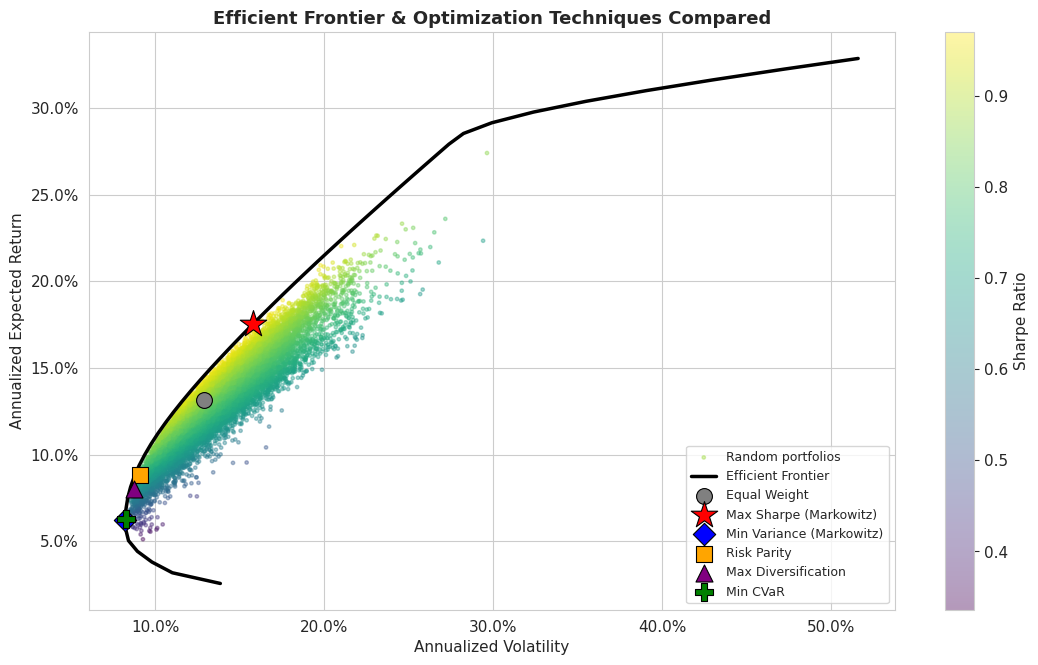

In [ ]:

cloud = optimizer.random_portfolio_cloud(CFG.n_random_portfolios)
frontier = optimizer.efficient_frontier(50)

plt.figure(figsize=(13, 7.5))
sc = plt.scatter(cloud["volatility"], cloud["return"], c=cloud["sharpe"],
                  cmap="viridis", s=6, alpha=0.4, label="Random portfolios")
plt.colorbar(sc, label="Sharpe Ratio")
plt.plot(frontier["volatility"], frontier["return"], color="black", linewidth=2.5,
          label="Efficient Frontier")

markers = {"Max Sharpe (Markowitz)": ("*", "red", 400),
           "Min Variance (Markowitz)": ("D", "blue", 130),
           "Risk Parity": ("s", "orange", 130),
           "Max Diversification": ("^", "purple", 150),
           "Equal Weight": ("o", "gray", 130),
           "Min CVaR": ("P", "green", 150)}

for name, w in technique_weights.items():
    ret, vol, _ = optimizer.performance(w)
    mk, color, size = markers.get(name, ("o", "black", 100))
    plt.scatter(vol, ret, marker=mk, color=color, s=size, edgecolor="black",
                linewidth=0.8, label=name, zorder=5)

plt.title("Efficient Frontier & Optimization Techniques Compared")
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Expected Return")
plt.gca().xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.legend(loc="lower right", fontsize=9)
plt.show()



**How to read this chart:** the black curve is the efficient frontier — the best possible
return for each level of risk. Points *inside* the cloud but below the curve are
sub-optimal (a frontier portfolio dominates them). The colored markers show where each
optimization technique lands: Max-Sharpe sits at the point of tangency with the highest
risk-adjusted return; Min-Variance sits at the far-left tip (lowest possible risk); Risk
Parity and Max-Diversification typically land somewhat left-of-center, trading some return
for more balanced risk exposure; Min-CVaR usually sits close to Min-Variance but shaped by
the actual historical tail behavior rather than just variance.


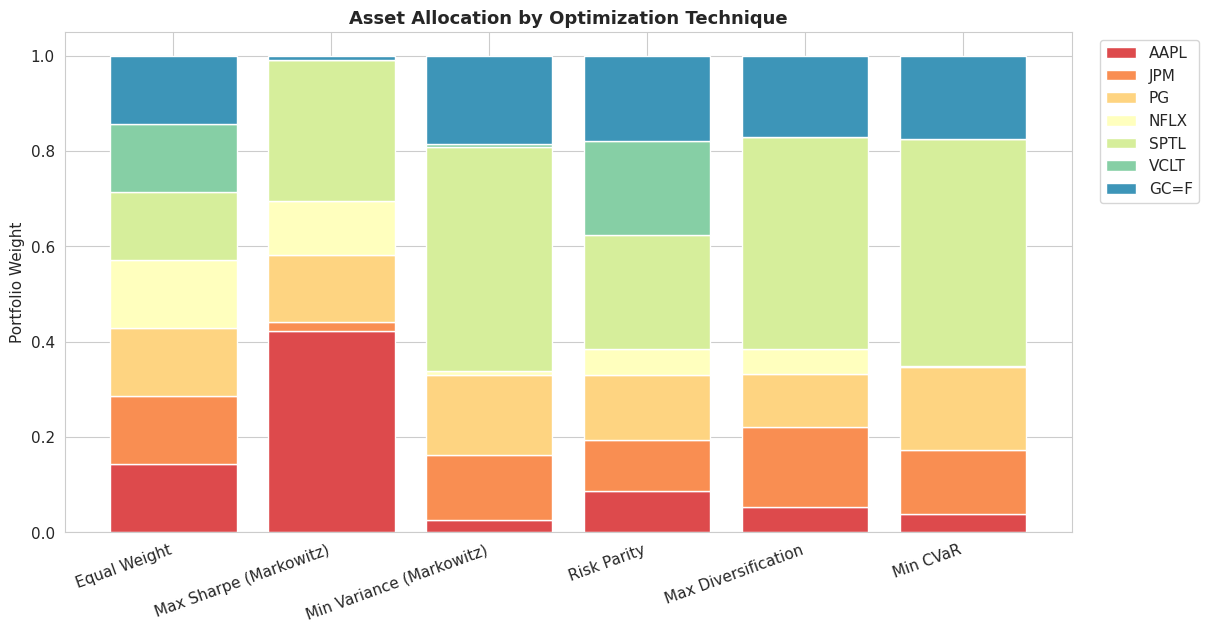

In [ ]:

weights_only = comparison_df.reset_index()[CFG.tickers]
weights_only.index = comparison_df.index

plt.figure(figsize=(13, 6.5))
bottom = np.zeros(len(weights_only))
colors = sns.color_palette("Spectral", len(CFG.tickers))
for i, asset in enumerate(CFG.tickers):
    plt.bar(weights_only.index, weights_only[asset], bottom=bottom, label=asset, color=colors[i])
    bottom += weights_only[asset].values
plt.title("Asset Allocation by Optimization Technique")
plt.ylabel("Portfolio Weight")
plt.xticks(rotation=20, ha="right")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()



### Risk Contribution: who's actually driving the risk?

Even a seemingly "diversified" portfolio (by dollar weight) can be risk-concentrated in
one or two volatile assets. The chart below decomposes total portfolio risk into each
asset's **percentage contribution** using $RC_i = w_i (\Sigma w)_i / \sigma_p$ (Section
4.1) — compare the Max-Sharpe portfolio (often risk-concentrated) against the Risk-Parity
portfolio (by construction, risk is spread evenly).


Risk contribution - Max Sharpe portfolio:


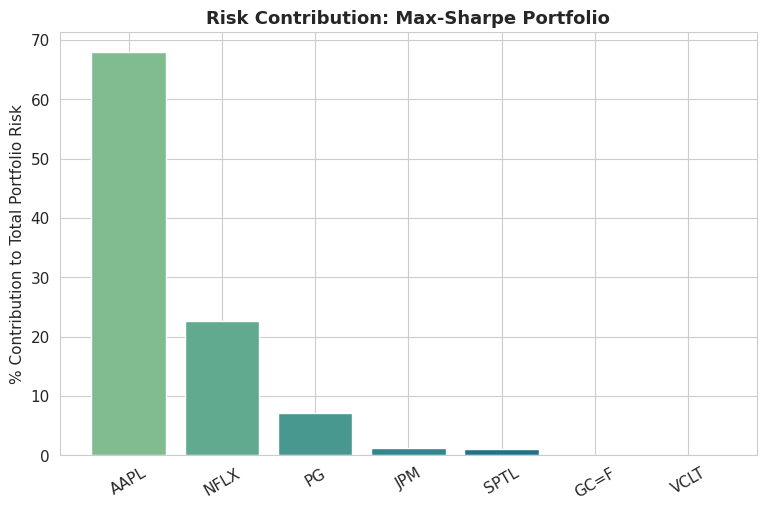

AAPL    67.96
JPM      1.18
PG       7.06
NFLX    22.62
SPTL     1.07
VCLT     0.00
GC=F     0.10
dtype: float64


In [ ]:

def plot_risk_contribution(weights, cov, asset_names, title):
    port_vol = np.sqrt(weights @ cov @ weights)
    marginal = cov @ weights / port_vol
    contrib = weights * marginal
    pct_contrib = contrib / contrib.sum() * 100

    plt.figure(figsize=(9, 5.5))
    order = np.argsort(pct_contrib)[::-1]
    colors = sns.color_palette("crest", len(asset_names))
    plt.bar(np.array(asset_names)[order], pct_contrib[order], color=colors)
    plt.title(title)
    plt.ylabel("% Contribution to Total Portfolio Risk")
    plt.xticks(rotation=30)
    plt.show()
    return pd.Series(pct_contrib, index=asset_names).round(2)


print("Risk contribution - Max Sharpe portfolio:")
rc1 = plot_risk_contribution(technique_weights["Max Sharpe (Markowitz)"],
                              data.cov_annual.values, CFG.tickers,
                              "Risk Contribution: Max-Sharpe Portfolio")
print(rc1)


Risk contribution - Risk Parity portfolio (should be ~equal across assets):


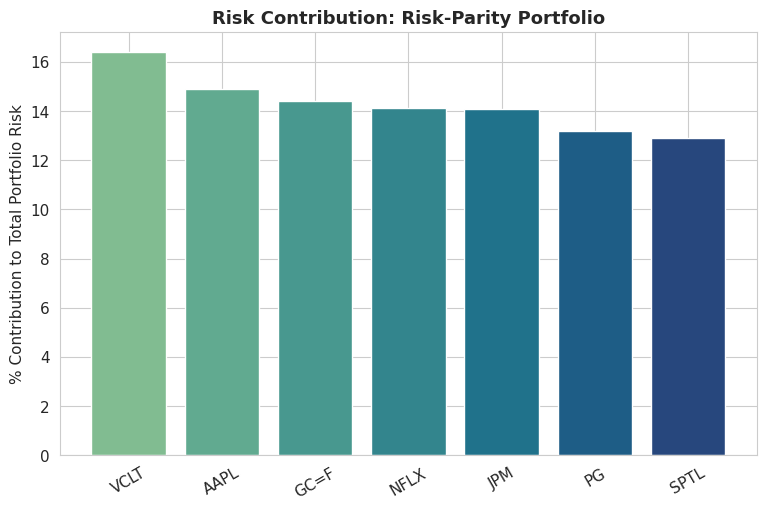

AAPL    14.91
JPM     14.09
PG      13.20
NFLX    14.11
SPTL    12.90
VCLT    16.40
GC=F    14.39
dtype: float64


In [ ]:

print("Risk contribution - Risk Parity portfolio (should be ~equal across assets):")
rc2 = plot_risk_contribution(technique_weights["Risk Parity"],
                              data.cov_annual.values, CFG.tickers,
                              "Risk Contribution: Risk-Parity Portfolio")
print(rc2)



## 6. Monte Carlo Simulation: Three Engines

Optimization tells us the *best* portfolio given our estimates of $\mu$ and $\Sigma$. Monte
Carlo simulation tells us **what could plausibly happen** to that portfolio's value over
time, by generating thousands of random future return paths consistent with the asset's
statistical properties.

### 6.1 Engine A — Cholesky-Decomposed Correlated Gaussian Shocks

We want to generate correlated random daily returns for $n$ assets that match the
covariance matrix $\Sigma$. The trick is **Cholesky decomposition**: any symmetric
positive-definite matrix $\Sigma$ can be factored as

$$
\Sigma = LL^T
$$

where $L$ is lower-triangular. If $Z \sim \mathcal{N}(0, I)$ is a vector of *independent*
standard normal shocks, then:

$$
X = LZ \quad \Longrightarrow \quad \text{Cov}(X) = L\,\text{Cov}(Z)\,L^T = LIL^T = LL^T = \Sigma
$$

So multiplying independent noise by $L$ "injects" the correct correlation structure. Daily
simulated returns are then:

$$
r_t = \mu + LZ_t, \qquad Z_t \sim \mathcal{N}(0, I)
$$

and the portfolio value path is the compounded product of daily portfolio returns:

$$
V_t = V_0 \prod_{s=1}^{t} (1 + w^T r_s)
$$

### 6.2 Engine B — Cholesky + Student-t Shocks (Fat Tails)

Real asset returns have **fatter tails** than a Gaussian — extreme moves (crashes) happen
more often than a normal distribution predicts. We replace the Gaussian shocks with
**Student-t** distributed shocks (with $\nu$ degrees of freedom, here $\nu=5$), rescaled
so variance still matches:

$$
Z_t \sim t_\nu \cdot \sqrt{\frac{\nu - 2}{\nu}}, \qquad r_t = \mu + L Z_t
$$

Lower $\nu$ → fatter tails → more frequent extreme simulated outcomes. This generally
widens the simulated distribution of outcomes and increases tail-risk estimates (VaR/CVaR)
relative to the pure Gaussian engine.

### 6.3 Engine C — Stationary Block Bootstrap

Both engines above assume returns are drawn from a fixed parametric distribution
(Gaussian or Student-t) with constant correlation. Real markets exhibit **volatility
clustering** (calm periods and turbulent periods cluster together) and time-varying
correlation that a parametric model misses. The **block bootstrap** sidesteps this
entirely: it randomly samples *contiguous blocks* of actual historical daily returns
(here, blocks of ~20 trading days) and stitches them together to build simulated paths.
This preserves whatever autocorrelation, clustering, and cross-asset relationships
actually existed in the historical data, with no distributional assumption at all.

### 6.4 Market-Regime Adjustment

To simulate a Bull, Bear, Recession, Stagflation, or Rate-Hike scenario (rather than just
"business as usual"), we scale the *mean* and *volatility* inputs before simulating:

$$
\mu_{regime} = \mu \cdot f_{ret}, \qquad \Sigma_{regime} = \Sigma \cdot f_{vol}^2
$$

where $f_{ret}$ and $f_{vol}$ are regime-specific multipliers calibrated from how
asset classes typically behave in each environment (e.g. Bull markets: higher mean,
lower volatility; Recessions: negative mean, much higher volatility).


In [ ]:

REGIME_FACTORS = {
    "Neutral":     dict(ret_factor=1.00, vol_factor=1.00),
    "Bull":        dict(ret_factor=2.20, vol_factor=0.80),
    "Bear":        dict(ret_factor=-1.20, vol_factor=1.20),
    "Recession":   dict(ret_factor=-1.80, vol_factor=1.50),
    "Stagflation": dict(ret_factor=-0.50, vol_factor=1.35),
    "Rate Hike":   dict(ret_factor=0.30, vol_factor=1.15),
}

regime_table = pd.DataFrame(REGIME_FACTORS).T
print("Market Regime Multipliers (applied to mean return & volatility):")
regime_table


Market Regime Multipliers (applied to mean return & volatility):


,ret_factor,vol_factor
Neutral,1.0,1.00
Bull,2.2,0.80
Bear,-1.2,1.20
Recession,-1.8,1.50
Stagflation,-0.5,1.35
Rate Hike,0.3,1.15


In [ ]:

class MonteCarloEngine:
    '''Simulates portfolio value paths using three interchangeable return-generating
    mechanisms: Gaussian (Cholesky), Student-t (Cholesky, fat tails), and block
    bootstrap of actual historical returns.'''

    def __init__(self, mean_returns: pd.Series, cov_matrix: pd.DataFrame,
                 daily_returns: pd.DataFrame, cfg: Config = CFG):
        self.mu = mean_returns.values
        self.cov = cov_matrix.values
        self.daily_returns = daily_returns.values
        self.n_assets = len(self.mu)
        self.cfg = cfg

    def _regime_adjusted_params(self, regime: str, inflation_daily: float):
        factors = REGIME_FACTORS.get(regime, REGIME_FACTORS["Neutral"])
        mu = self.mu * factors["ret_factor"] - inflation_daily
        cov = self.cov * (factors["vol_factor"] ** 2)
        return mu, cov

    def simulate_gaussian(self, weights, regime="Neutral", n_sims=None, horizon=None,
                           initial_value=None, inflation_daily=0.00008):
        n_sims = n_sims or self.cfg.n_simulations
        horizon = horizon or self.cfg.horizon_days
        initial_value = initial_value or self.cfg.initial_value

        mu, cov = self._regime_adjusted_params(regime, inflation_daily)
        L = np.linalg.cholesky(cov + 1e-12 * np.eye(self.n_assets))

        z = np.random.standard_normal((horizon, n_sims, self.n_assets))
        correlated_shocks = z @ L.T
        daily_asset_returns = mu + correlated_shocks
        daily_port_returns = daily_asset_returns @ weights

        growth = np.cumprod(1 + daily_port_returns, axis=0)
        return growth * initial_value

    def simulate_student_t(self, weights, regime="Neutral", n_sims=None, horizon=None,
                            initial_value=None, dof=5, inflation_daily=0.00008):
        n_sims = n_sims or self.cfg.n_simulations
        horizon = horizon or self.cfg.horizon_days
        initial_value = initial_value or self.cfg.initial_value

        mu, cov = self._regime_adjusted_params(regime, inflation_daily)
        L = np.linalg.cholesky(cov + 1e-12 * np.eye(self.n_assets))

        t_scale = np.sqrt((dof - 2) / dof) if dof > 2 else 1.0
        t_draws = stats.t.rvs(dof, size=(horizon, n_sims, self.n_assets)) * t_scale
        correlated_shocks = t_draws @ L.T
        daily_asset_returns = mu + correlated_shocks
        daily_port_returns = daily_asset_returns @ weights

        growth = np.cumprod(1 + daily_port_returns, axis=0)
        return growth * initial_value

    def simulate_block_bootstrap(self, weights, n_sims=None, horizon=None,
                                  initial_value=None, block_size=None):
        n_sims = n_sims or self.cfg.n_simulations
        horizon = horizon or self.cfg.horizon_days
        initial_value = initial_value or self.cfg.initial_value
        block_size = block_size or self.cfg.block_size

        T = self.daily_returns.shape[0]
        n_blocks_needed = int(np.ceil(horizon / block_size))
        growth = np.ones((horizon, n_sims))

        for sim in range(n_sims):
            start_idxs = np.random.randint(0, T - block_size, size=n_blocks_needed)
            path = np.concatenate(
                [self.daily_returns[s:s + block_size] for s in start_idxs], axis=0
            )[:horizon]
            port_ret = path @ weights
            growth[:, sim] = np.cumprod(1 + port_ret)

        return growth * initial_value


mc = MonteCarloEngine(data.expected_returns_daily, data.cov_daily, data.daily_returns, CFG)
print("MonteCarloEngine ready (Gaussian / Student-t / Block-Bootstrap).")


MonteCarloEngine ready (Gaussian / Student-t / Block-Bootstrap).



## 7. Risk Metrics: Quantifying "How Bad Could It Get?"

### 7.1 Value at Risk (VaR) and Conditional Value at Risk (CVaR)

At confidence level $1-\alpha$ (e.g. 95%, so $\alpha = 5$):

$$
\text{VaR}_\alpha = -\text{Percentile}_\alpha(\text{returns})
$$

VaR answers: *"What's the most I could lose, 95% of the time?"* But VaR says nothing
about how bad the remaining 5% could be. **CVaR** (a.k.a. Expected Shortfall) fixes this
by averaging all outcomes *worse* than the VaR threshold:

$$
\text{CVaR}_\alpha = -\mathbb{E}\big[r \mid r \leq -\text{VaR}_\alpha\big]
$$

CVaR is always $\geq$ VaR, and is considered a more complete (and "coherent") risk
measure since it captures tail severity, not just the threshold.

### 7.2 Maximum Drawdown

The largest peak-to-trough decline along a single simulated path:

$$
\text{MDD} = \min_t \left(\frac{V_t}{\max_{s \leq t} V_s} - 1\right)
$$

### 7.3 Sharpe & Sortino Ratios

Sharpe (Section 3.2) penalizes *all* volatility, even upside surprises. **Sortino ratio**
only penalizes *downside* volatility, which arguably better matches how investors actually
feel about risk:

$$
\text{Sortino} = \frac{R_p - r_f}{\sigma_{downside}}, \qquad
\sigma_{downside} = \text{std}\big(\{r_t : r_t < r_f\}\big)
$$

### 7.4 CAGR (Compound Annual Growth Rate)

$$
\text{CAGR} = \left(\frac{V_T}{V_0}\right)^{1/y} - 1, \qquad y = \frac{\text{horizon in days}}{252}
$$


In [ ]:

class RiskMetrics:

    @staticmethod
    def var_historical(returns, alpha):
        return -min(0, np.percentile(returns, alpha))

    @staticmethod
    def cvar_historical(returns, alpha):
        var_cutoff = np.percentile(returns, alpha)
        tail = returns[returns <= var_cutoff]
        return -min(0, tail.mean()) if len(tail) else 0.0

    @staticmethod
    def max_drawdown_path(values):
        running_max = np.maximum.accumulate(values)
        drawdown = values / running_max - 1.0
        return drawdown.min()

    @classmethod
    def summarize_simulation(cls, sim_matrix, initial_value, risk_free_rate,
                              horizon_days, loss_threshold, alpha):
        final_values = sim_matrix[-1, :]
        total_returns = (final_values - initial_value) / initial_value
        years = horizon_days / CFG.trading_days

        cagr = (final_values.mean() / initial_value) ** (1 / years) - 1
        expected_return = total_returns.mean()
        volatility = total_returns.std()
        excess = total_returns - risk_free_rate * years
        sharpe = excess.mean() / excess.std() if excess.std() > 0 else 0.0
        prob_loss = (total_returns < loss_threshold).mean() * 100

        var_mc = cls.var_historical(total_returns, alpha) * initial_value
        cvar_mc = cls.cvar_historical(total_returns, alpha) * initial_value

        drawdowns = np.array([cls.max_drawdown_path(sim_matrix[:, i])
                               for i in range(min(sim_matrix.shape[1], 2000))])

        return {
            "Expected Return": expected_return, "Volatility": volatility,
            "Sharpe Ratio": sharpe, "CAGR": cagr,
            "Prob. of Loss > Threshold (%)": prob_loss,
            "VaR ($)": var_mc, "CVaR ($)": cvar_mc,
            "Avg Max Drawdown (%)": drawdowns.mean() * 100,
            "Worst-Case Max Drawdown (%)": drawdowns.min() * 100,
            "Median Final Value ($)": np.median(final_values),
            "5th Pct Final Value ($)": np.percentile(final_values, 5),
            "95th Pct Final Value ($)": np.percentile(final_values, 95),
        }


print("RiskMetrics ready.")


RiskMetrics ready.



## 8. Running the Simulation: 1-Year Outlook for All Three Portfolios

For each of the Aggressive / Moderate / Conservative portfolios, we run all three Monte
Carlo engines over a 1-year (252 trading day) horizon starting from a **$100,000**
initial investment, in a **Neutral** market regime, and compare the resulting risk/return
statistics.


In [ ]:

sim_results = {}
summary_rows = []

for name, w in portfolios.items():
    sim_gauss = mc.simulate_gaussian(w, regime="Neutral")
    sim_t = mc.simulate_student_t(w, regime="Neutral", dof=5)
    sim_boot = mc.simulate_block_bootstrap(w)
    sim_results[name] = sim_gauss

    for engine_name, sim in [("Gaussian (Cholesky)", sim_gauss),
                              ("Student-t (fat tails)", sim_t),
                              ("Block Bootstrap", sim_boot)]:
        s = RiskMetrics.summarize_simulation(sim, CFG.initial_value, CFG.risk_free_rate,
                                              CFG.horizon_days, CFG.loss_threshold, CFG.var_alpha)
        summary_rows.append({"Portfolio": name, "Engine": engine_name, **s})

mc_summary_df = pd.DataFrame(summary_rows)
print("Monte Carlo Simulation Results (1-Year Horizon, Neutral Regime):")
mc_summary_df[["Portfolio", "Engine", "Expected Return", "Volatility", "Sharpe Ratio",
               "CAGR", "VaR ($)", "CVaR ($)"]].round(4)


Monte Carlo Simulation Results (1-Year Horizon, Neutral Regime):


,Portfolio,Engine,Expected Return,Volatility,Sharpe Ratio,CAGR,VaR ($),CVaR ($)
0,Aggressive,Gaussian (Cholesky),0.1495,0.2106,0.6151,0.1495,15933.9310,22045.4325
1,Aggressive,Student-t (fat tails),0.1501,0.2052,0.6339,0.1501,15679.4790,21370.1881
2,Aggressive,Block Bootstrap,0.1821,0.2082,0.7785,0.1821,14044.8250,21642.9324
3,Moderate,Gaussian (Cholesky),0.1182,0.1604,0.6121,0.1182,12278.1135,17051.1547
4,Moderate,Student-t (fat tails),0.1208,0.1573,0.6410,0.1208,11824.0534,16634.5941
5,Moderate,Block Bootstrap,0.1437,0.1624,0.7615,0.1437,11610.2629,17349.6460
6,Conservative,Gaussian (Cholesky),0.0832,0.1184,0.5338,0.0832,10017.9770,13993.1267
7,Conservative,Student-t (fat tails),0.0817,0.1174,0.5257,0.0817,10264.0436,14011.7779
8,Conservative,Block Bootstrap,0.1105,0.1267,0.7145,0.1105,9833.3684,15094.0354



**Comparing engines:** the Student-t engine typically produces slightly wider VaR/CVaR
estimates than the Gaussian engine (fatter tails → more extreme simulated outcomes), while
the Block Bootstrap reflects whatever volatility clustering and skew genuinely existed in
the historical data — sometimes more extreme, sometimes less, depending on what crises
the sample period actually contained.


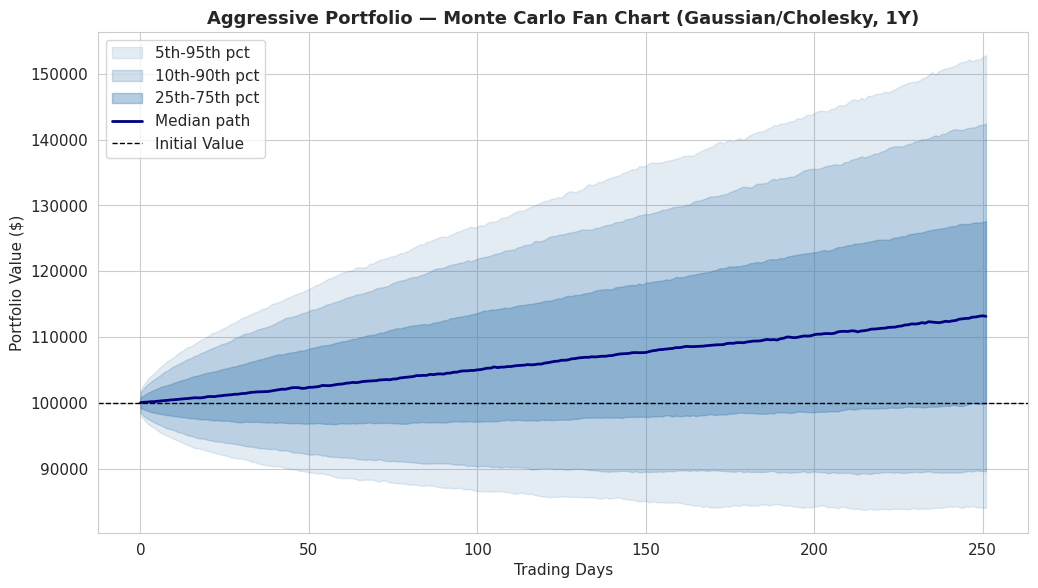

In [ ]:

def mc_fan_chart(sim_matrix, title):
    horizon = sim_matrix.shape[0]
    x = np.arange(horizon)
    pct = {p: np.percentile(sim_matrix, p, axis=1) for p in [5, 10, 25, 50, 75, 90, 95]}

    plt.figure(figsize=(12, 6.5))
    plt.fill_between(x, pct[5], pct[95], color="steelblue", alpha=0.15, label="5th-95th pct")
    plt.fill_between(x, pct[10], pct[90], color="steelblue", alpha=0.25, label="10th-90th pct")
    plt.fill_between(x, pct[25], pct[75], color="steelblue", alpha=0.40, label="25th-75th pct")
    plt.plot(x, pct[50], color="navy", linewidth=2, label="Median path")
    plt.axhline(CFG.initial_value, color="black", linestyle="--", linewidth=1, label="Initial Value")
    plt.title(title)
    plt.xlabel("Trading Days")
    plt.ylabel("Portfolio Value ($)")
    plt.legend(loc="upper left")
    plt.show()


mc_fan_chart(sim_results["Aggressive"],
             "Aggressive Portfolio — Monte Carlo Fan Chart (Gaussian/Cholesky, 1Y)")


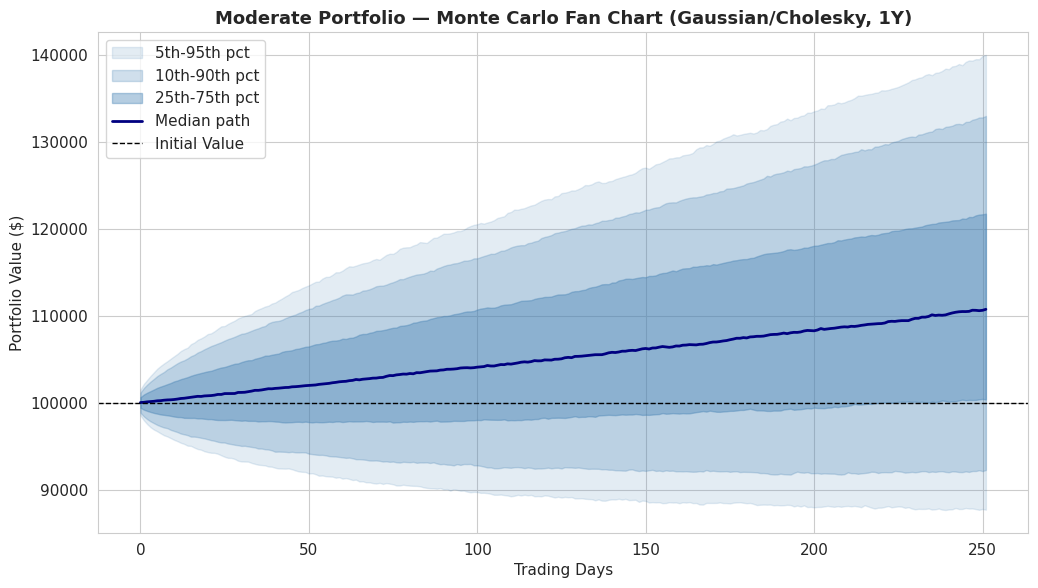

In [ ]:

mc_fan_chart(sim_results["Moderate"],
             "Moderate Portfolio — Monte Carlo Fan Chart (Gaussian/Cholesky, 1Y)")


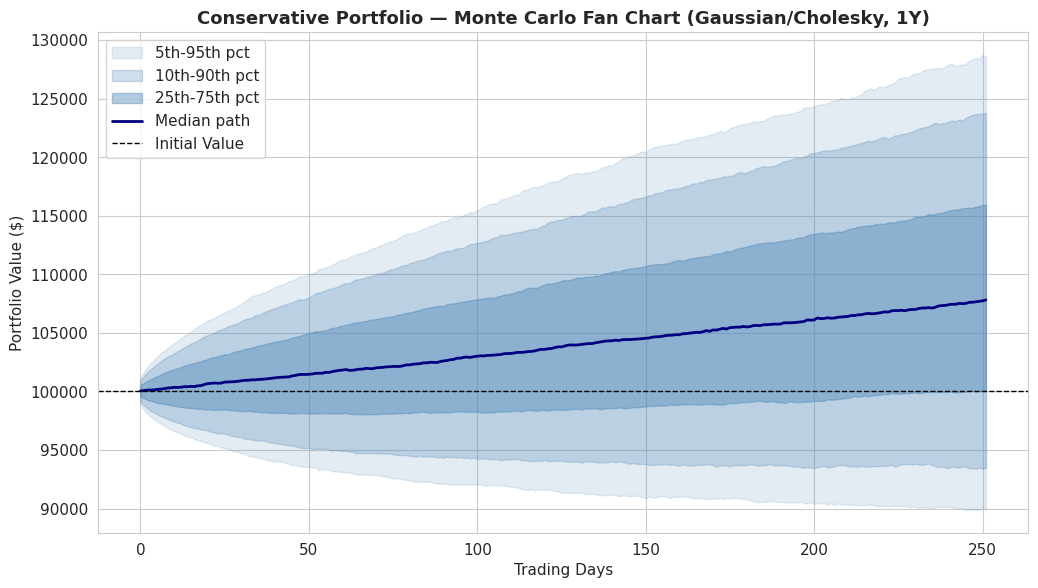

In [ ]:

mc_fan_chart(sim_results["Conservative"],
             "Conservative Portfolio — Monte Carlo Fan Chart (Gaussian/Cholesky, 1Y)")



**Reading a fan chart:** this replaces the old "spaghetti plot" of thousands of overlapping
lines with percentile bands — the darkest band is the 25th-75th percentile range (where the
portfolio value lands half the time), widening out to the 5th-95th percentile band (a 90%
confidence range). The navy line is the median outcome. Wider bands = more uncertainty;
notice the Aggressive portfolio's fan widens much faster than the Conservative one's.


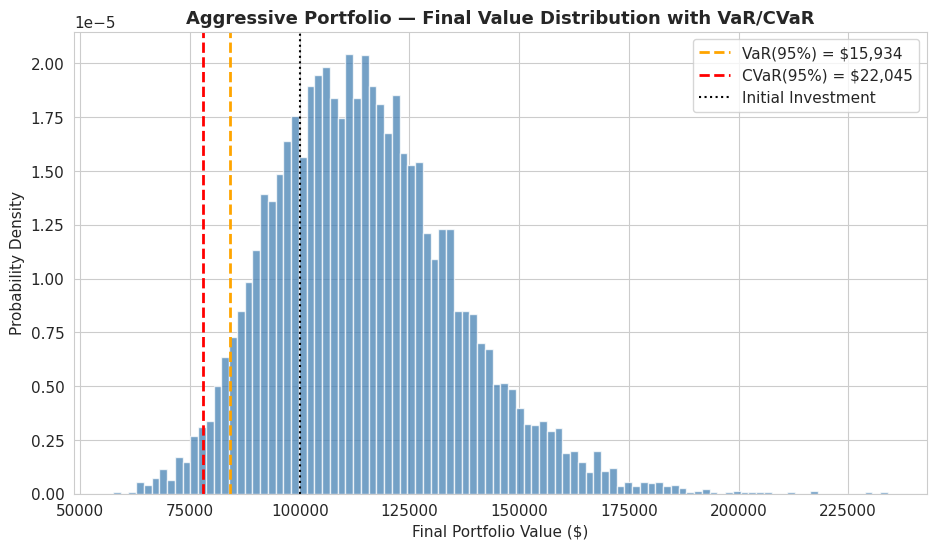

In [ ]:

def plot_return_distribution(sim_matrix, initial_value, var_dollar, cvar_dollar, title):
    final_values = sim_matrix[-1, :]
    plt.figure(figsize=(11, 6))
    plt.hist(final_values, bins=100, density=True, alpha=0.75, color="steelblue")
    var_level = initial_value - var_dollar
    cvar_level = initial_value - cvar_dollar
    plt.axvline(var_level, color="orange", linestyle="--", linewidth=2,
                label=f"VaR(95%) = ${var_dollar:,.0f}")
    plt.axvline(cvar_level, color="red", linestyle="--", linewidth=2,
                label=f"CVaR(95%) = ${cvar_dollar:,.0f}")
    plt.axvline(initial_value, color="black", linestyle=":", linewidth=1.5, label="Initial Investment")
    plt.title(title)
    plt.xlabel("Final Portfolio Value ($)")
    plt.ylabel("Probability Density")
    plt.legend()
    plt.show()


stats_agg = RiskMetrics.summarize_simulation(sim_results["Aggressive"], CFG.initial_value,
                                              CFG.risk_free_rate, CFG.horizon_days,
                                              CFG.loss_threshold, CFG.var_alpha)
plot_return_distribution(sim_results["Aggressive"], CFG.initial_value,
                          stats_agg["VaR ($)"], stats_agg["CVaR ($)"],
                          "Aggressive Portfolio — Final Value Distribution with VaR/CVaR")


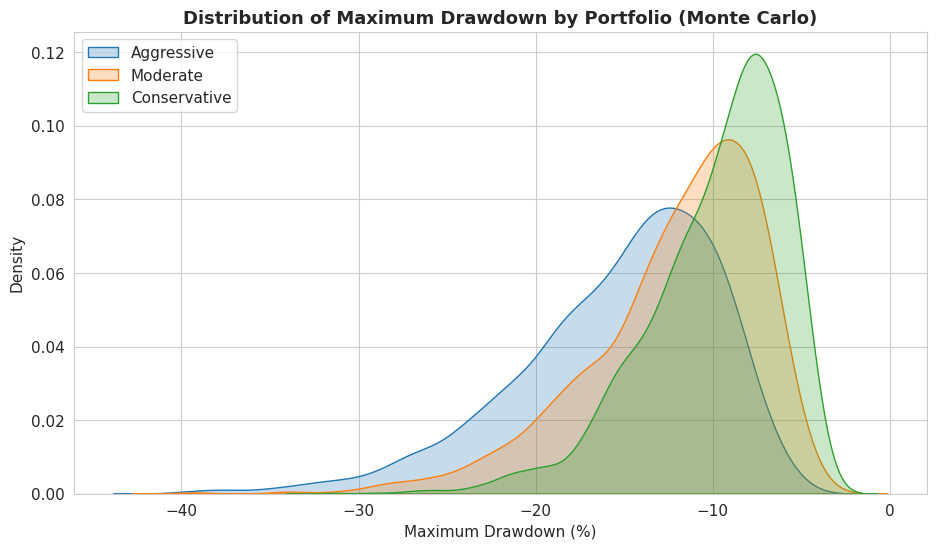

In [ ]:

def drawdown_comparison(sim_dict):
    plt.figure(figsize=(11, 6))
    for name, sim in sim_dict.items():
        n_paths = min(sim.shape[1], 2000)
        dds = [RiskMetrics.max_drawdown_path(sim[:, i]) * 100 for i in range(n_paths)]
        sns.kdeplot(dds, label=name, fill=True, alpha=0.25)
    plt.title("Distribution of Maximum Drawdown by Portfolio (Monte Carlo)")
    plt.xlabel("Maximum Drawdown (%)")
    plt.ylabel("Density")
    plt.legend()
    plt.show()


drawdown_comparison(sim_results)



## 9. Scenario Analysis: How Do Portfolios Behave Across Market Regimes?

Using the regime-adjustment mechanism from Section 6.4, we now run the Monte Carlo engine
across **every combination** of portfolio × regime × horizon, and summarize results in
heatmaps. This answers questions like: *"If we hit a recession, how much worse does the
Aggressive portfolio fare relative to Conservative — and by how much does that gap close
or widen over different time horizons?"*


In [ ]:

def run_scenario_analysis(portfolios, mc, horizons, regimes=None, n_sims=2000):
    regimes = regimes or list(REGIME_FACTORS.keys())
    rows = []
    for pf_name, weights in portfolios.items():
        for regime in regimes:
            for horizon in horizons:
                sim = mc.simulate_gaussian(weights, regime=regime, n_sims=n_sims, horizon=horizon)
                s = RiskMetrics.summarize_simulation(sim, CFG.initial_value, CFG.risk_free_rate,
                                                      horizon, CFG.loss_threshold, CFG.var_alpha)
                rows.append({"Portfolio": pf_name, "Regime": regime,
                             "Horizon (yrs)": round(horizon / CFG.trading_days, 1), **s})
    return pd.DataFrame(rows)


print("Running scenario analysis across all market regimes (this may take a moment) ...")
scenario_df = run_scenario_analysis(portfolios, mc, horizons=[63, 252, 252 * 5], n_sims=2000)
print(f"Done — {len(scenario_df)} scenario combinations evaluated.")
scenario_df.head(8).round(3)


Running scenario analysis across all market regimes (this may take a moment) ...
Done — 54 scenario combinations evaluated.


,Portfolio,Regime,Horizon (yrs),Expected Return,Volatility,Sharpe Ratio,CAGR,Prob. of Loss > Threshold (%),VaR ($),CVaR ($),Avg Max Drawdown (%),Worst-Case Max Drawdown (%),Median Final Value ($),5th Pct Final Value ($),95th Pct Final Value ($)
0,Aggressive,Neutral,0.2,0.038,0.094,0.353,0.162,6.75,11108.775,14226.261,-8.242,-26.503,103397.981,88891.225,120094.969
1,Aggressive,Neutral,1.0,0.156,0.213,0.640,0.156,9.30,15127.941,21438.773,-15.278,-44.660,113402.819,84872.059,155571.024
2,Aggressive,Neutral,5.0,0.996,0.826,1.085,0.148,3.40,1737.806,16363.197,-26.491,-63.793,185217.294,98262.194,360576.608
3,Aggressive,Bull,0.2,0.085,0.078,1.022,0.384,0.70,3959.980,6688.249,-5.307,-16.346,108213.209,96040.020,121344.423
4,Aggressive,Bull,1.0,0.396,0.194,1.940,0.396,0.15,0.000,0.000,-8.452,-23.646,138493.503,110129.344,174002.359
5,Aggressive,Bull,5.0,4.240,1.765,2.346,0.393,0.00,0.000,0.000,-12.882,-34.961,496212.715,283091.459,835830.636
6,Aggressive,Bear,0.2,-0.055,0.101,-0.594,-0.203,34.30,20737.033,24127.924,-13.591,-33.218,93806.084,79262.967,112277.990
7,Aggressive,Bear,1.0,-0.193,0.178,-1.200,-0.193,73.05,44420.907,49260.360,-30.958,-62.280,78634.430,55579.093,112714.185


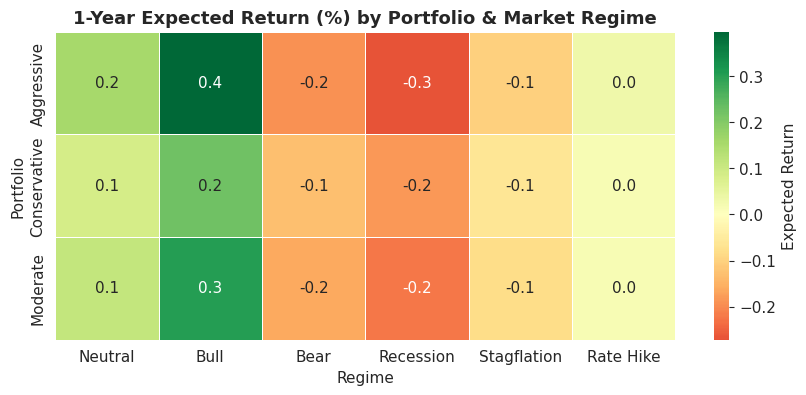

In [ ]:

def scenario_heatmap(scenario_df, metric, title=None):
    pivot = scenario_df.pivot_table(index="Portfolio", columns="Regime", values=metric, aggfunc="mean")
    order = [r for r in REGIME_FACTORS if r in pivot.columns]
    pivot = pivot[order]
    plt.figure(figsize=(10, 4))
    sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn", center=0,
                linewidths=0.5, cbar_kws={"label": metric})
    plt.title(title or f"Scenario Analysis: {metric} by Portfolio & Market Regime")
    plt.show()


one_year = scenario_df[scenario_df["Horizon (yrs)"] == 1.0]
scenario_heatmap(one_year, "Expected Return",
                  "1-Year Expected Return (%) by Portfolio & Market Regime")


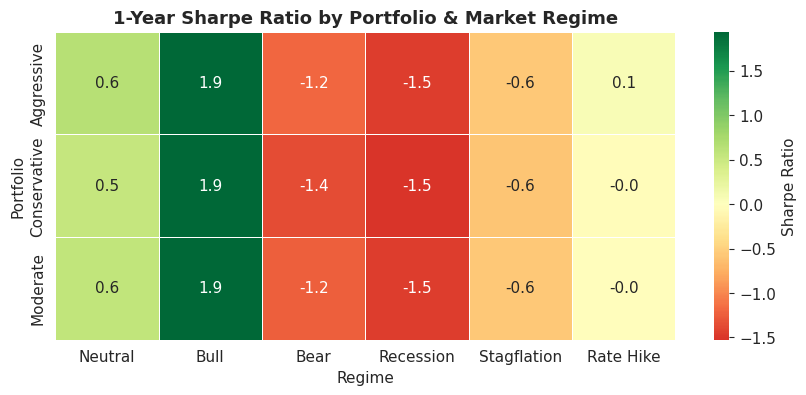

In [ ]:

scenario_heatmap(one_year, "Sharpe Ratio", "1-Year Sharpe Ratio by Portfolio & Market Regime")


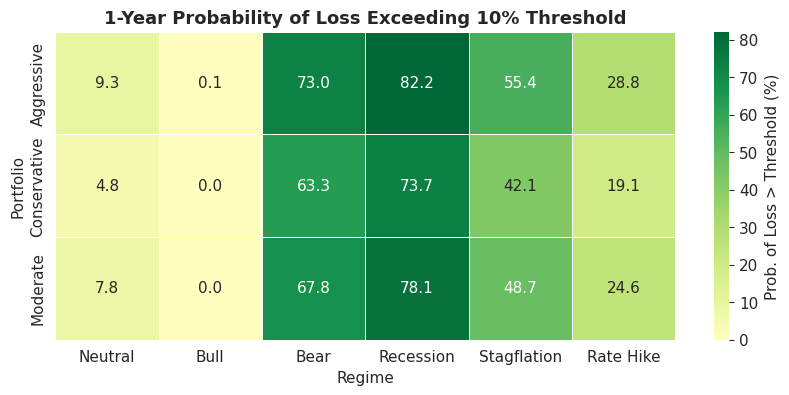

In [ ]:

scenario_heatmap(one_year, "Prob. of Loss > Threshold (%)",
                  "1-Year Probability of Loss Exceeding 10% Threshold")



**Key pattern to look for:** in Bull/Neutral regimes, Aggressive typically dominates on
return and often on Sharpe too. In Bear/Recession/Stagflation regimes, the ranking flips —
Conservative's bond-heavy allocation cushions the blow, while Aggressive's equity-heavy mix
amplifies losses. This regime-dependence is exactly why a single backtested Sharpe ratio is
an incomplete picture — the "best" portfolio depends on which regime materializes.



## 10. Stress Testing: Historical Crises + Hypothetical Shocks

Scenario analysis (Section 9) tells us about *simulated* regimes. Stress testing instead
asks two more concrete questions:

1. **What actually happened to this portfolio during real historical crises?** — computed
   directly from realized asset returns during known crisis windows.
2. **What would happen under a hypothetical instantaneous shock** (e.g. "equities crash
   30% overnight") that may not be represented in the historical sample at all?

### 10.1 Historical Stress Windows

For a crisis window $[t_0, t_1]$, the realized portfolio return is simply:

$$
R_p^{[t_0,t_1]} = w^T \left(\frac{P_{t_1}}{P_{t_0}} - 1\right)
$$

i.e. the weighted sum of each asset's actual cumulative return over that exact window —
no simulation, no assumptions, just what the market actually did.

### 10.2 Hypothetical Instantaneous Shocks

For a hypothetical shock vector $s$ (e.g. "equities $-30\%$, bonds $+5\%$, gold $+10\%$"),
the instant portfolio impact is just $w^T s$ — useful for stress-testing against scenarios
that haven't happened yet (or happened before the data window starts), like a sudden
correlated equity selloff or an aggressive rate-hike shock to bonds.

### 10.3 Correlation Breakdown Test

A subtle but critical risk: diversification benefits can **vanish exactly when you need
them most**. In a genuine crisis, correlations across asset classes often spike toward 1
("everything sells off together"). We test this by holding each asset's own variance fixed
but forcing all pairwise correlations toward a stressed value (e.g. 0.9), and comparing
portfolio volatility under normal vs. crisis correlation:

$$
\sigma_p^{crisis} = \sqrt{w^T \Sigma^{crisis} w}, \qquad
\Sigma^{crisis}_{ij} = \rho_{stress} \cdot \sigma_i \sigma_j \ \ (i \neq j)
$$


In [ ]:

HISTORICAL_STRESS_WINDOWS = {
    "Aug 2015 China Selloff":     ("2015-08-10", "2015-08-25"),
    "Dec 2018 Selloff":           ("2018-10-01", "2018-12-24"),
    "COVID-19 Crash":             ("2020-02-19", "2020-03-23"),
    "2022 Bear Market":           ("2022-01-03", "2022-10-12"),
    "2023 Banking Crisis (SVB)":  ("2023-03-08", "2023-03-13"),
}


def historical_stress_test(portfolios, prices):
    rows = []
    for event, (start, end) in HISTORICAL_STRESS_WINDOWS.items():
        window = prices.loc[(prices.index >= start) & (prices.index <= end)]
        if len(window) < 2:
            continue
        period_return = window.iloc[-1] / window.iloc[0] - 1
        for pf_name, weights in portfolios.items():
            port_return = float(np.dot(weights, period_return.values))
            rows.append({"Stress Event": event, "Window": f"{start} to {end}",
                         "Portfolio": pf_name, "Portfolio Return (%)": port_return * 100})
    return pd.DataFrame(rows)


hist_stress = historical_stress_test(portfolios, data.prices)
print("Historical Stress Test Results:")
hist_stress.round(2)


Historical Stress Test Results:


,Stress Event,Window,Portfolio,Portfolio Return (%)
0,Aug 2015 China Selloff,2015-08-10 to 2015-08-25,Aggressive,-10.88
1,Aug 2015 China Selloff,2015-08-10 to 2015-08-25,Moderate,-8.04
2,Aug 2015 China Selloff,2015-08-10 to 2015-08-25,Conservative,-5.30
3,Dec 2018 Selloff,2018-10-01 to 2018-12-24,Aggressive,-18.99
4,Dec 2018 Selloff,2018-10-01 to 2018-12-24,Moderate,-14.26
5,Dec 2018 Selloff,2018-10-01 to 2018-12-24,Conservative,-9.61
6,COVID-19 Crash,2020-02-19 to 2020-03-23,Aggressive,-21.92
7,COVID-19 Crash,2020-02-19 to 2020-03-23,Moderate,-17.90
8,COVID-19 Crash,2020-02-19 to 2020-03-23,Conservative,-13.09
9,2022 Bear Market,2022-01-03 to 2022-10-12,Aggressive,-33.32


In [ ]:

HYPOTHETICAL_SHOCKS = {
    "Equity Crash (-30%)":               {"_default_equity": -0.30, "_default_bond": 0.05, "GC=F": 0.10},
    "Rates +200bps (bond selloff)":      {"_default_equity": -0.03, "_default_bond": -0.12, "GC=F": -0.02},
    "Stagflation Shock":                 {"_default_equity": -0.15, "_default_bond": -0.08, "GC=F": 0.15},
    "Single-Asset Collapse (NFLX -50%)": {"NFLX": -0.50},
    "Flight to Safety":                  {"_default_equity": -0.10, "_default_bond": 0.04, "GC=F": 0.08},
}

EQUITY_TICKERS = {"AAPL", "JPM", "PG", "NFLX"}
BOND_TICKERS = {"SPTL", "VCLT"}


def hypothetical_shock_test(portfolios, tickers):
    rows = []
    for shock_name, shock_map in HYPOTHETICAL_SHOCKS.items():
        shock_vec = np.zeros(len(tickers))
        for i, t in enumerate(tickers):
            if t in shock_map:
                shock_vec[i] = shock_map[t]
            elif t in EQUITY_TICKERS and "_default_equity" in shock_map:
                shock_vec[i] = shock_map["_default_equity"]
            elif t in BOND_TICKERS and "_default_bond" in shock_map:
                shock_vec[i] = shock_map["_default_bond"]
        for pf_name, weights in portfolios.items():
            port_shock = float(np.dot(weights, shock_vec))
            rows.append({"Shock Scenario": shock_name, "Portfolio": pf_name,
                         "Instant Portfolio Impact (%)": port_shock * 100})
    return pd.DataFrame(rows)


hypo_stress = hypothetical_shock_test(portfolios, CFG.tickers)
print("Hypothetical Shock Scenarios:")
hypo_stress.round(2)


Hypothetical Shock Scenarios:


,Shock Scenario,Portfolio,Instant Portfolio Impact (%)
0,Equity Crash (-30%),Aggressive,-22.75
1,Equity Crash (-30%),Moderate,-15.50
2,Equity Crash (-30%),Conservative,-8.50
3,Rates +200bps (bond selloff),Aggressive,-4.30
4,Rates +200bps (bond selloff),Moderate,-5.60
5,Rates +200bps (bond selloff),Conservative,-7.40
6,Stagflation Shock,Aggressive,-12.45
7,Stagflation Shock,Moderate,-9.90
8,Stagflation Shock,Conservative,-8.50
9,Single-Asset Collapse (NFLX -50%),Aggressive,-10.00


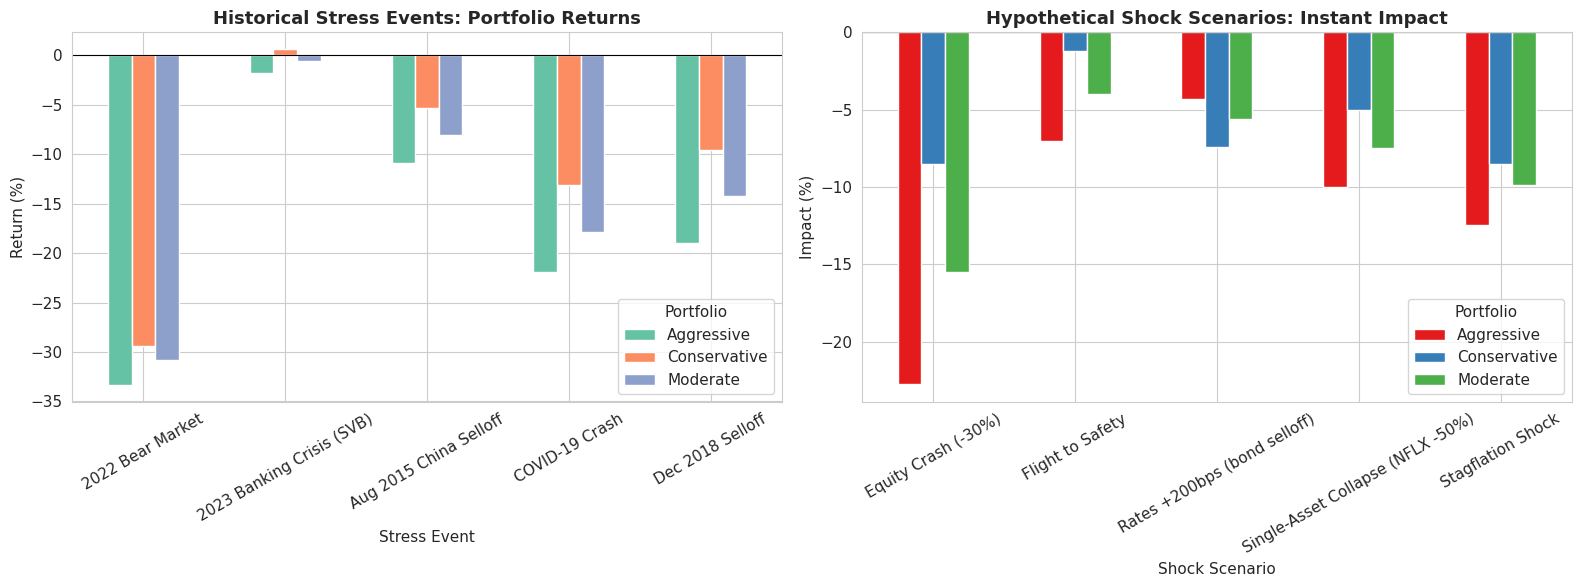

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pivot1 = hist_stress.pivot_table(index="Stress Event", columns="Portfolio", values="Portfolio Return (%)")
pivot1.plot(kind="bar", ax=axes[0], color=sns.color_palette("Set2", 3))
axes[0].set_title("Historical Stress Events: Portfolio Returns")
axes[0].set_ylabel("Return (%)")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].tick_params(axis="x", rotation=30)

pivot2 = hypo_stress.pivot_table(index="Shock Scenario", columns="Portfolio", values="Instant Portfolio Impact (%)")
pivot2.plot(kind="bar", ax=axes[1], color=sns.color_palette("Set1", 3))
axes[1].set_title("Hypothetical Shock Scenarios: Instant Impact")
axes[1].set_ylabel("Impact (%)")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


In [ ]:

def correlation_breakdown_test(portfolios, cov_matrix, stress_corr=0.9):
    std = np.sqrt(np.diag(cov_matrix.values))
    stressed_corr = np.full(cov_matrix.shape, stress_corr)
    np.fill_diagonal(stressed_corr, 1.0)
    stressed_cov = stressed_corr * np.outer(std, std)

    rows = []
    for pf_name, weights in portfolios.items():
        normal_vol = np.sqrt(weights @ cov_matrix.values @ weights)
        stressed_vol = np.sqrt(weights @ stressed_cov @ weights)
        rows.append({
            "Portfolio": pf_name,
            "Normal Volatility (%)": normal_vol * 100,
            "Crisis Volatility (%)": stressed_vol * 100,
            "Volatility Increase (%)": (stressed_vol / normal_vol - 1) * 100,
        })
    return pd.DataFrame(rows)


corr_break = correlation_breakdown_test(portfolios, data.cov_annual)
print("Correlation Breakdown Test (portfolio volatility: normal vs. crisis correlation regime):")
corr_break.round(2)


Correlation Breakdown Test (portfolio volatility: normal vs. crisis correlation regime):


,Portfolio,Normal Volatility (%),Crisis Volatility (%),Volatility Increase (%)
0,Aggressive,18.09,27.24,50.58
1,Moderate,14.13,23.73,67.98
2,Conservative,10.92,20.15,84.46



**Why this matters:** notice that the *Conservative* portfolio often shows the **largest
percentage increase** in volatility under correlation breakdown, even though its absolute
crisis volatility may still be lower than Aggressive's. That's because Conservative
portfolios rely more heavily on the assumption that bonds will keep diversifying against
equities — when that assumption breaks down in a genuine liquidity crisis, the relative
shock to a "safe" portfolio's risk profile can be proportionally larger. This is a classic,
underappreciated tail risk in conservative, bond-heavy allocations.



## 11. Summary & Takeaways

- **Optimization technique choice matters**: Max-Sharpe maximizes risk-adjusted return but
  can concentrate risk in a few assets; Risk Parity and Max-Diversification spread risk
  more evenly at some cost to expected return; Min-CVaR explicitly targets tail risk using
  actual historical scenarios rather than just variance.
- **No single Monte Carlo engine is "the truth"**: Gaussian/Cholesky is fast and analytically
  clean but understates tail risk; Student-t fixes that with minimal extra cost; Block
  Bootstrap is the most data-driven but limited to patterns that occurred historically.
- **Regime matters more than headline Sharpe ratio**: a portfolio that looks great in a
  Neutral/Bull backtest can underperform sharply in Bear/Recession/Stagflation regimes —
  always evaluate across multiple regimes, not just the historical average.
- **Diversification can fail exactly when you need it most**: the correlation breakdown
  test is a reminder that "safe" allocations built on historical correlation assumptions
  carry their own hidden tail risk.

All tables in this notebook were also exported as CSV files (if you run the optional export
cell below) for further analysis in Excel or other tools.


In [ ]:

import os
OUTPUT_DIR = "portfolio_analysis_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

comparison_df.round(4).to_csv(os.path.join(OUTPUT_DIR, "optimization_comparison.csv"))
mc_summary_df.round(4).to_csv(os.path.join(OUTPUT_DIR, "monte_carlo_summary.csv"), index=False)
scenario_df.round(4).to_csv(os.path.join(OUTPUT_DIR, "scenario_analysis.csv"), index=False)
hist_stress.round(2).to_csv(os.path.join(OUTPUT_DIR, "historical_stress_test.csv"), index=False)
hypo_stress.round(2).to_csv(os.path.join(OUTPUT_DIR, "hypothetical_stress_test.csv"), index=False)
corr_break.round(2).to_csv(os.path.join(OUTPUT_DIR, "correlation_breakdown_test.csv"), index=False)

print(f"All result tables exported to ./{OUTPUT_DIR}/")
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(" -", f)


All result tables exported to ./portfolio_analysis_output/
 - correlation_breakdown_test.csv
 - historical_stress_test.csv
 - hypothetical_stress_test.csv
 - monte_carlo_summary.csv
 - optimization_comparison.csv
 - scenario_analysis.csv
